<a href="https://colab.research.google.com/github/ParshavGiya/SOP_IPD_Simulation/blob/main/Iterative_Prisoner's_Dilemma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import random
import math
class Player:
    def __init__(self, strategy):
        self.strategy = strategy
        self.score = 0
        self.last_strategy = None

    def move(self):
        if self.strategy == "always_cooperate":
            move = "C"

        elif self.strategy == "always_defect":
            move = "D"

        else:
            raise ValueError(f"Unknown strategy: {self.strategy}")

        return move

In [82]:
# Defining payoffs(using the same notations of the paper)
R = 1 #Both Cooperate
T = 1.7 #The Lone Defectors Reward
P = 0.3 #Both Defect
S = 0 #The Lone Cooperator

In [83]:
# Payoffs, the way to score basically

def payoffs(m1,m2):
  if (m1 == "C" and m2 == "C"):
    return R,R
  elif (m1 == "C" and m2 == "D"):
    return S,T
  elif (m1 == "D" and m2 == "D"):
    return P,P
  else:
    return T,S

In [84]:
def play_round_self(player):
  if (player.strategy == "always_cooperate"):
    player.score = player.score + 1
  else:
    player.score = player.score

In [85]:
# Trying out one round of iteration with 2 players
#(Although haven't defined p1 or p2 yet)

def play_round(p1,p2):
  m1 = p1.move()
  m2 = p2.move()

  s1,s2 = payoffs(m1,m2)
  p1.score = p1.score + s1
  p2.score = p2.score + s2

In [86]:
## Grid time, This gives a random grid

def create_grid(n, proportions):
  total_cells = n*n

  strategy_list = []

  for strategy, fraction in proportions.items():
    count = int(fraction*total_cells)
    strategy_list.extend([strategy]*count)

  while len(strategy_list) < total_cells:
    strategy_list.append("always_cooperate")

  random.shuffle(strategy_list)
  grid= []
  index =0

  for i in range(n):
    row = []
    for j in range(n):
      row.append(Player(strategy_list[index]))
      index = index +1
    grid.append(row)

  return grid

In [87]:
def create_single_defector_grid(n=99):
    grid = []

    for i in range(n):
        row = []
        for j in range(n):
            # center cell
            if i == n // 2 and j == n // 2:
                strategy = "always_defect"
            else:
                strategy = "always_cooperate"

            row.append(Player(strategy))
        grid.append(row)

    return grid

In [88]:
def get_neighbors_8(grid, x, y):
    n = len(grid)
    neighbors = []

    directions = [
        (-1,-1), (-1,0), (-1,1),
        (0,-1),          (0,1),
        (1,-1),  (1,0),  (1,1)
    ]

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < n and 0 <= ny < n:
            neighbors.append(grid[nx][ny])

    return neighbors

In [89]:
def get_neighbors_4(grid, x, y):
    n = len(grid)
    neighbors = []

    directions = [(0,1),(1,-1),(1,0),(1,1)]

    for dx, dy in directions:
        nx, ny = x + dx, y + dy

        if 0 <= nx < n and 0 <= ny < n:
            neighbors.append(grid[nx][ny])

    return neighbors

In [90]:
def interaction_step(grid):
    n = len(grid)

    for i in range(n):
        for j in range(n):
            player = grid[i][j]
            neighbors = get_neighbors_4(grid, i, j)

            play_round_self(player)

            for neighbor in neighbors:
                play_round(player, neighbor)

In [91]:
def update_strategies(grid):
    n = len(grid)

    new_strategies = []
    for i in range(n):
        row = [None] * n
        new_strategies.append(row)

    for i in range(n):
        for j in range(n):
            player = grid[i][j]
            neighbors = get_neighbors_8(grid, i, j)

            best_player = player

            for neighbor in neighbors:
                if neighbor.score > best_player.score:
                    best_player = neighbor

            new_strategies[i][j] = best_player.strategy

    for i in range(n):
        for j in range(n):
          grid[i][j].last_strategy = grid[i][j].strategy

    # apply updates (synchronous)
    for i in range(n):
        for j in range(n):
            grid[i][j].strategy = new_strategies[i][j]

In [92]:
def reset_scores(grid):
    for row in grid:
        for player in row:
            player.score = 0

In [93]:
def run_simulation(grid, steps):
    import numpy as np
    import matplotlib.pyplot as plt

    plt.figure()

    for step in range(steps):
        global P
        P = 0 + 0.2 * np.sin(step * 2)

        print(f"Step {step}: P = {P:.4f}")

        reset_scores(grid)
        interaction_step(grid)
        update_strategies(grid)

        plot_grid(grid, step)

    plt.show()

In [94]:
def plot_coop_and_p_over_time(grid, steps):
    import matplotlib.pyplot as plt
    import numpy as np

    coop_fractions = []
    p_values = []

    for step in range(steps):
        # --- Oscillating P (actual simulation) ---
        global P
        P = 0 + 0.1 * np.sin(step * 5)
        p_values.append(P)

        print(f"Step {step}: P = {P:.4f}")

        # --- Game dynamics ---
        reset_scores(grid)
        interaction_step(grid)
        update_strategies(grid)

        # --- Compute fraction of cooperators ---
        n = len(grid)
        total = n * n
        coop = 0

        for row in grid:
            for player in row:
                if player.strategy == "always_cooperate":
                    coop += 1

        coop_fractions.append(coop / total)

    # --- Create smooth P for plotting only ---
    smooth_factor = 10
    fine_steps = np.arange(0, steps, 1 / smooth_factor)
    smooth_p = 0.1 * np.sin(fine_steps * 5)

    # --- Plot ---
    fig, ax1 = plt.subplots()

    ax1.plot(coop_fractions, label="Cooperators", color='blue')
    ax1.set_xlabel("Time (generations)")
    ax1.set_ylabel("Fraction of Cooperators", color='blue')

    ax2 = ax1.twinx()
    ax2.plot(fine_steps, smooth_p, color='orange', alpha=0.7)
    ax2.set_ylabel("P value", color='orange')

    plt.title("Cooperators vs Oscillating P")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    fig.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    plt.show()

In [95]:
import matplotlib.pyplot as plt
import numpy as np

def plot_grid(grid, step):
    n = len(grid)
    data = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            player = grid[i][j]

            if player.strategy == "always_cooperate":
                value = 0   # blue
            else:
                value = 1   # red

            data[i][j] = value

    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["blue", "red"])

    plt.imshow(data, cmap=cmap)
    plt.title(f"Step {step}")
    plt.axis('off')
    plt.pause(0.01)
    plt.clf()

Step 0: P = 0.0000
Step 1: P = -0.0959
Step 2: P = -0.0544
Step 3: P = 0.0650
Step 4: P = 0.0913
Step 5: P = -0.0132
Step 6: P = -0.0988
Step 7: P = -0.0428
Step 8: P = 0.0745
Step 9: P = 0.0851
Step 10: P = -0.0262
Step 11: P = -0.1000
Step 12: P = -0.0305
Step 13: P = 0.0827
Step 14: P = 0.0774
Step 15: P = -0.0388
Step 16: P = -0.0994
Step 17: P = -0.0176
Step 18: P = 0.0894
Step 19: P = 0.0683
Step 20: P = -0.0506
Step 21: P = -0.0971
Step 22: P = -0.0044
Step 23: P = 0.0945
Step 24: P = 0.0581
Step 25: P = -0.0616
Step 26: P = -0.0930
Step 27: P = 0.0088
Step 28: P = 0.0980
Step 29: P = 0.0468
Step 30: P = -0.0715
Step 31: P = -0.0873
Step 32: P = 0.0219
Step 33: P = 0.0998
Step 34: P = 0.0347
Step 35: P = -0.0801
Step 36: P = -0.0801
Step 37: P = 0.0347
Step 38: P = 0.0998
Step 39: P = 0.0219
Step 40: P = -0.0873
Step 41: P = -0.0715
Step 42: P = 0.0468
Step 43: P = 0.0980
Step 44: P = 0.0088
Step 45: P = -0.0930
Step 46: P = -0.0616
Step 47: P = 0.0581
Step 48: P = 0.0945
Step 4

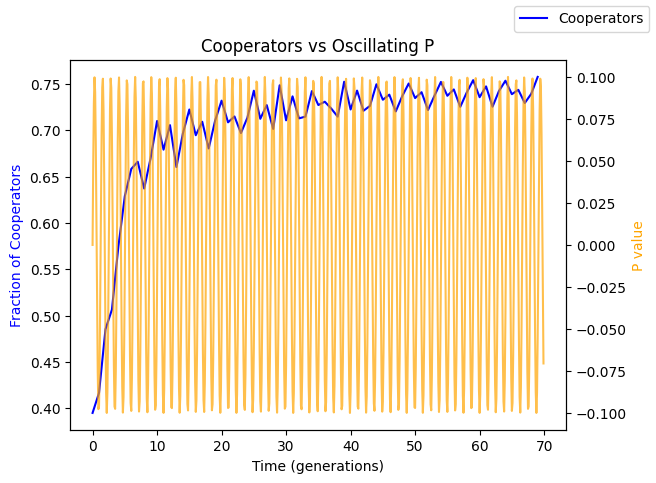

In [96]:
grid = create_grid(200, {"always_cooperate": 0.9,"always_defect": 0.1})

# grid = create_single_defector_grid(99)

# run_simulation(grid, 1000)

plot_coop_and_p_over_time(grid, 70)